In [1]:
import os
import sys
import numpy as np
import torch
import glob
import yaml
import csv
import pandas as pd

import matplotlib.pyplot as plt

src_path = os.path.abspath(os.path.join(os.getcwd(), '../..', 'src'))

if src_path not in sys.path:
    sys.path.append(src_path)

from utils.ks_loader import KSLoader
from training_managment.factory import Factory

../../data
/Users/marco/Documents/PhD/HFNO/notebooks/ks_equation


# Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data loading

In [6]:
args = {"m": 256,
        "nx": 1024,
        "nu": 0.7,
        "L": 22.0,
        "batch_size": 64}

x_coordinates = np.arange(0, args["L"], args["nx"])
tl = 12.478292398441297

In [7]:
datasets = KSLoader(args)

# Model loading (Layer's number analysis)

In [14]:
model_list = []
error_list = []
models_path = "../../runs/kuramoto_sivashinsky/hfno_hyperparameters_search_nlay"
for n_lay in [1,2,4,8,16]:
    model_path = os.path.join(models_path, f"experiment_hfno_layer_modes_{n_lay}", "logs", "metrics.csv")
    with open(model_path, "r") as f:
        reader = csv.DictReader(f)
        error_list.append(np.min([float(row["Te relative_rmse"]) for row in reader]))

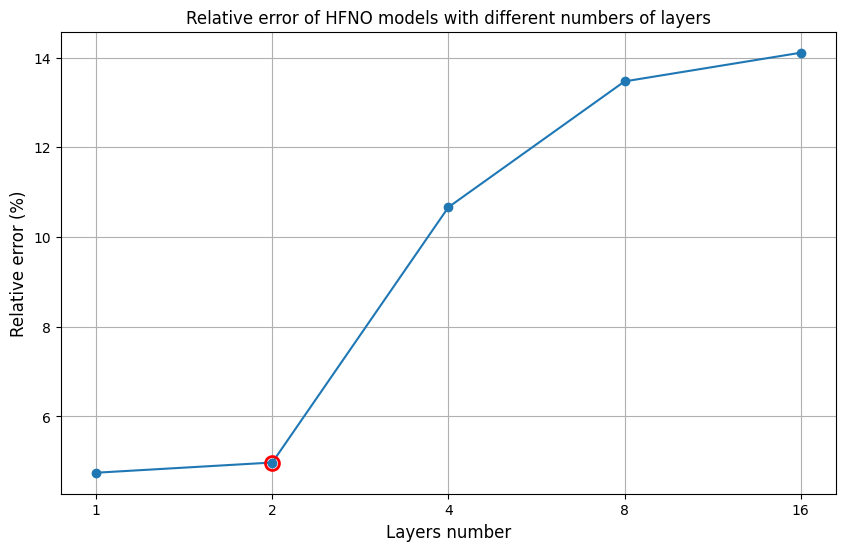

In [15]:
plt.figure(figsize=(10,6))
error_list = 100*np.array(error_list)
plt.plot(range(1,len(error_list)+1), error_list, marker='o')

i=2
plt.plot(i, error_list[i-1], 'ro', markersize=10, markerfacecolor='none', markeredgewidth=2)

plt.title("Relative error of HFNO models with different numbers of layers")
plt.xlabel("Layers number", fontsize=12)
plt.ylabel("Relative error (%)", fontsize=12)
x_ticks = range(1, len(error_list)+1)
plt.xticks(x_ticks, [str(2**i) for i in range(len(error_list))])
plt.grid()


In [8]:
model_list = []
models_path = "../../runs/kuramoto_sivashinsky/hfno_hyperparameters_search_nlay"
for n_lay in [1,2,4,8,16]:
    model_path = os.path.join(models_path, f"experiment_hfno_layer_modes_{n_lay}", "config.yaml")
    with open(model_path, "r") as f:
        args = yaml.safe_load(f)
    model = Factory.get_model(args["model"], args, device)
    model.load_state_dict(torch.load(os.path.join(models_path, f"experiment_hfno_layer_modes_{n_lay}/model_weights", "min_test_loss.pth"))["model_state_dict"])
    model_list.append(model)
error_list = []
for model in model_list:
    model.eval()
    with torch.no_grad():
        error = 0
        for input, target in datasets.testing_set:
            input_traj = torch.tensor(input, dtype=torch.float32).to(device)
            output_traj = model(input_traj).cpu().numpy()
            target = target.cpu().numpy()
            error_batch = np.sqrt(np.mean((output_traj - target)**2, axis=1) / np.mean((target)**2, axis=1)).mean()
            error += error_batch
        error /= len(datasets.testing_set)
        error_list.append(error)
        print(f"Relative error for model with k_sep={model.layer_modes} : {error}")
        
        

/var/folders/53/d3ng48y138s7ldywsyn64jj00000gn/T/ipykernel_55670/2601985615.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_traj = torch.tensor(input, dtype=torch.float32).to(device)


Relative error for model with k_sep=[16] : 0.08259477466344833
Relative error for model with k_sep=[8, 16] : 0.07999353110790253
Relative error for model with k_sep=[4, 8, 12, 16] : 0.10271499305963516
Relative error for model with k_sep=[2, 4, 6, 8, 10, 12, 14, 16] : 0.10198519378900528
Relative error for model with k_sep=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16] : 0.0918157547712326


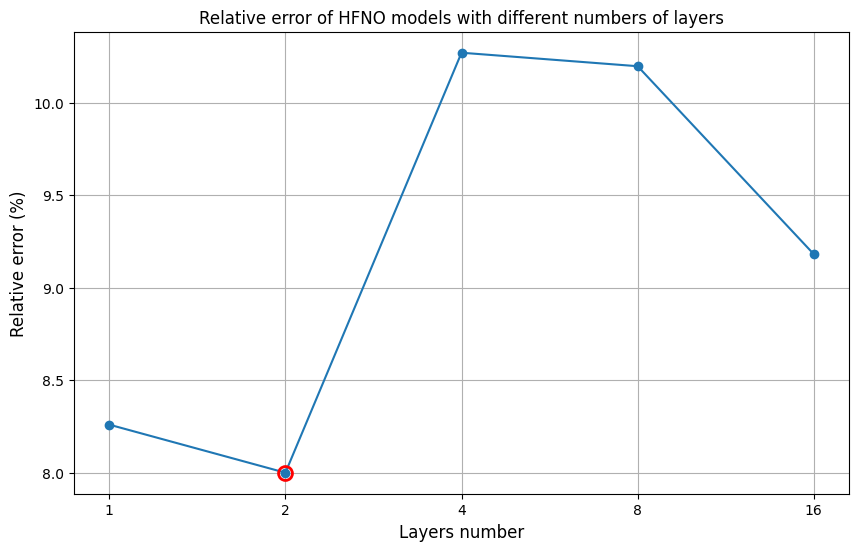

In [9]:
plt.figure(figsize=(10,6))
error_list = 100*np.array(error_list)
plt.plot(range(1,len(error_list)+1), error_list, marker='o')

i=2
plt.plot(i, error_list[i-1], 'ro', markersize=10, markerfacecolor='none', markeredgewidth=2)

plt.title("Relative error of HFNO models with different numbers of layers")
plt.xlabel("Layers number", fontsize=12)
plt.ylabel("Relative error (%)", fontsize=12)
x_ticks = range(1, len(error_list)+1)
plt.xticks(x_ticks, [str(2**i) for i in range(len(error_list))])
plt.grid()


# Model loading (Layer's configuration analysis)

In [18]:
model_list = []
error_list = []
models_path = "../../runs/kuramoto_sivashinsky/hfno_hyperparameters_search"

for k_sep in range(1,16):
    model_path = os.path.join(models_path, f"experiment_hfno_layer_modes_{k_sep}_16", "logs/metrics.csv")
    with open(model_path, "r") as f:
        reader = csv.DictReader(f)
        error_list.append(np.min([float(row["Te relative_rmse"]) for row in reader]))
   

In [13]:
error_list = []
for model in model_list:
    model.eval()
    with torch.no_grad():
        error = 0
        for input, target in datasets.testing_set:
            input_traj = torch.tensor(input, dtype=torch.float32).to(device)
            output_traj = model(input_traj).cpu().numpy()
            target = target.cpu().numpy()
            error_batch = np.sqrt(np.mean((output_traj - target)**2, axis=1) / np.mean((target)**2, axis=1)).mean()
            error += error_batch
        error /= len(datasets.testing_set)
        error_list.append(error)
        print(f"Relative error for model with k_sep={model.layer_modes} : {error}")
        

/var/folders/53/d3ng48y138s7ldywsyn64jj00000gn/T/ipykernel_51561/4143668755.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_traj = torch.tensor(input, dtype=torch.float32).to(device)


Relative error for model with k_sep=[1, 16] : 0.03979130834341049
Relative error for model with k_sep=[2, 16] : 0.03659427911043167
Relative error for model with k_sep=[3, 16] : 0.037098370492458344
Relative error for model with k_sep=[4, 16] : 0.03467780351638794
Relative error for model with k_sep=[5, 16] : 0.0352078378200531
Relative error for model with k_sep=[6, 16] : 0.036504168063402176
Relative error for model with k_sep=[7, 16] : 0.04796368256211281
Relative error for model with k_sep=[8, 16] : 0.0463629886507988
Relative error for model with k_sep=[9, 16] : 0.058139901608228683
Relative error for model with k_sep=[10, 16] : 0.06557904928922653
Relative error for model with k_sep=[11, 16] : 0.07343817502260208
Relative error for model with k_sep=[12, 16] : 0.07432601600885391
Relative error for model with k_sep=[13, 16] : 0.07304792106151581
Relative error for model with k_sep=[14, 16] : 0.06380360573530197
Relative error for model with k_sep=[15, 16] : 0.05224892124533653


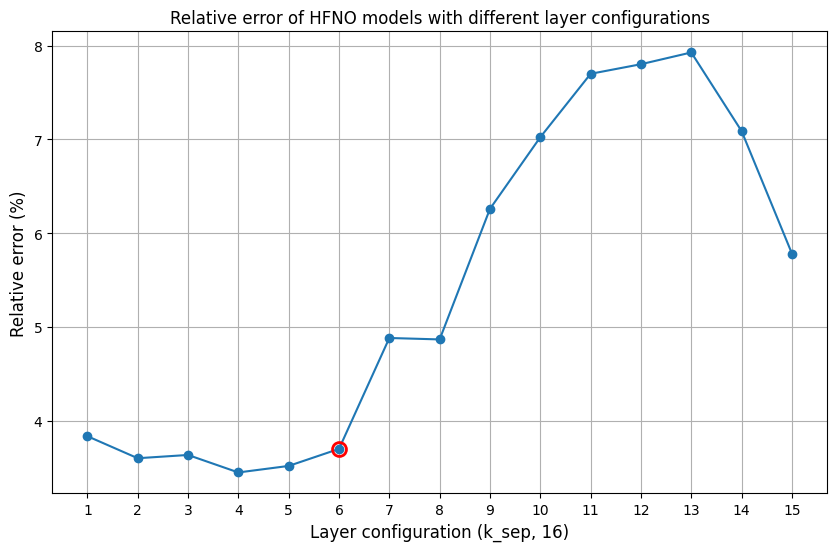

In [19]:
plt.figure(figsize=(10,6))
error_list = 100*np.array(error_list)
plt.plot(range(1,16), error_list, marker='o')
i=6
plt.plot(i, error_list[i-1], 'ro', markersize=10, markerfacecolor='none', markeredgewidth=2)

plt.title("Relative error of HFNO models with different layer configurations")
plt.xlabel("Layer configuration (k_sep, 16)", fontsize=12)
plt.ylabel("Relative error (%)", fontsize=12)
plt.xticks(range(1,16))
plt.grid()

# Model visualization

In [23]:
model_hfno_path = "../../runs/kuramoto_sivashinsky/experiment12"

config_path = os.path.join(model_hfno_path, "config.yaml")
with open(config_path, "r") as f:
    args = yaml.safe_load(f)

model_hfno = Factory.get_model(args["model"], args, device)
model_hfno.load_state_dict(torch.load(os.path.join(model_hfno_path, "model_weights", "min_test_loss.pth"))["model_state_dict"])

<All keys matched successfully>

In [25]:
traj_test = datasets.input_test[:1851]
traj_test_out = datasets.output_test[:1851].cpu().numpy().T

In [26]:
traj_test.shape

torch.Size([1851, 256])

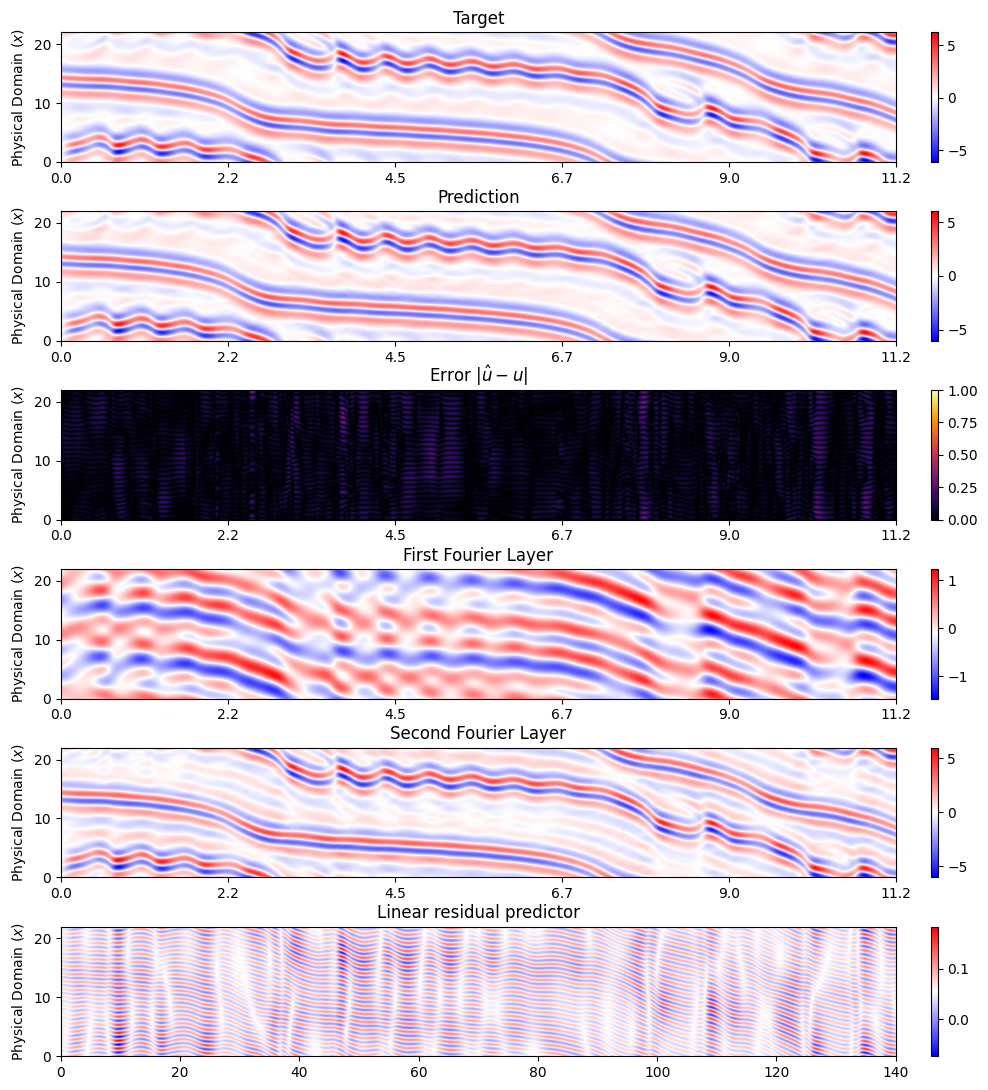

In [28]:
i_model = 5

with torch.no_grad():
    preds_train = model_hfno(traj_test.to(device)).cpu().numpy()
    preds_train_1 = model_hfno(traj_test.to(device), indexes=[0], sum_w=False).cpu().numpy()
    preds_train_2 = model_hfno(traj_test.to(device), indexes=[1], sum_w=False).cpu().numpy()
    preds_train_w = model_hfno(traj_test.to(device), indexes=0, sum_w=True).cpu().numpy()


error_train = np.abs(preds_train-traj_test_out.T)


L = 22  # Domain
T = 150  # Time
discard = 10.

x = torch.linspace(0, L, traj_test_out.T.shape[0])
t = torch.linspace(0, T, traj_test_out.T.shape[1])

nT = traj_test.shape[1]
nt_start = int(discard/T*nT)
Tf = T - discard

vmin = min(traj_test_out.min(), preds_train.min())
vmax = max(traj_test_out.max(), preds_train.max())

fig, axs = plt.subplots(6, 1, figsize=(10,11))

#fig.subplots_adjust(hspace=0.5)

im1 = axs[0].imshow(traj_test_out, extent=[0, Tf, 0, L], aspect='auto', origin='lower', cmap='bwr')
axs[0].set_title("Target", fontsize=12)
axs[0].set_ylabel(r"Physical Domain $(x)$", fontsize=10)
#axs[0].set_xlabel(r"Time $(t)$", fontsize=10)
fig.colorbar(im1, ax=axs[0], orientation='vertical', fraction=0.02, pad=0.04)

im2 = axs[1].imshow(preds_train.T, extent=[0, Tf, 0, L], aspect='auto', origin='lower', cmap='bwr')
axs[1].set_title("Prediction", fontsize=12)
axs[1].set_ylabel(r"Physical Domain $(x)$", fontsize=10)
#axs[1].set_xlabel(r"Time $(t)$", fontsize=10)
fig.colorbar(im2, ax=axs[1], orientation='vertical', fraction=0.02, pad=0.04)

im3 = axs[2].imshow(error_train.T, extent=[0, Tf, 0, L], aspect='auto', origin='lower', cmap='inferno', vmin=0, vmax=1)
axs[2].set_title(f"Error $|\hat u - u|$", fontsize=12)
axs[2].set_ylabel(r"Physical Domain $(x)$", fontsize=10)
#axs[2].set_xlabel(r"Time $(t)$", fontsize=10)
fig.colorbar(im3, ax=axs[2], orientation='vertical', fraction=0.02, pad=0.04)

im4 = axs[3].imshow(preds_train_1.T, extent=[0, Tf, 0, L], aspect='auto', origin='lower', cmap='bwr')
axs[3].set_title(f"First Fourier Layer", fontsize=12)
axs[3].set_ylabel(r"Physical Domain $(x)$", fontsize=10)
#axs[3].set_xlabel(r"Time $(t)$", fontsize=10)
fig.colorbar(im4, ax=axs[3], orientation='vertical', fraction=0.02, pad=0.04)

im5 = axs[4].imshow(preds_train_2.T, extent=[0, Tf, 0, L], aspect='auto', origin='lower', cmap='bwr')
axs[4].set_title(f"Second Fourier Layer", fontsize=12)
axs[4].set_ylabel(r"Physical Domain $(x)$", fontsize=10)
#axs[4].set_xlabel(r"Time $(t)$", fontsize=10)
fig.colorbar(im5, ax=axs[4], orientation='vertical', fraction=0.02, pad=0.04)

im6 = axs[5].imshow(preds_train_w.T, extent=[0, Tf, 0, L], aspect='auto', origin='lower', cmap='bwr')
axs[5].set_title(f"Linear residual predictor", fontsize=12)
axs[5].set_ylabel(r"Physical Domain $(x)$", fontsize=10)
#axs[5].set_xlabel(r"Time $(t)$", fontsize=10)
fig.colorbar(im6, ax=axs[5], orientation='vertical', fraction=0.02, pad=0.04)


xticks = np.linspace(0, Tf, 6)
for i in range(5):  
    axs[i].set_xticks(xticks)
    axs[i].set_xticklabels([f"{x/tl:.1f}" for x in xticks])


# Ajuster la mise en page
plt.tight_layout(h_pad=-0.1)
if not os.path.exists("plots"):
    os.mkdir("plots")
plt.show()

In [40]:
np.sqrt(np.mean(np.sum((traj_test_out - preds_train_1.T)**2, axis=1)/np.sum(traj_test_out**2, axis=1)))

np.float32(0.9539839)

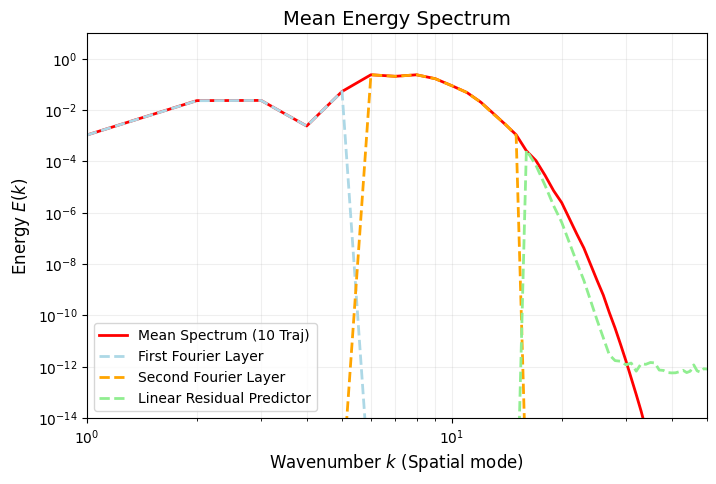

In [41]:
def energy_spectrum(u):
    nx, nt = u.shape 
    u_norm = u - np.mean(u, axis=0, keepdims=True)
    fft_u = np.fft.rfft(u_norm, axis=0)
    E_hat = np.mean(np.abs(fft_u)**2, axis=1) / (nx**2)
    kx = np.fft.rfftfreq(nx, d=1.0) * nx
    mask = E_hat > 0
    return E_hat[mask], kx[mask]

# --- Adapted Code for Mean Spectrum ---

#plt.figure(figsize=(8, 5))


k_shared = None

E_k, k = energy_spectrum(traj_test_out)
 
E_k_1, k1 = energy_spectrum(preds_train_1.T)
E_k_2, k2 = energy_spectrum(preds_train_2.T)
E_k_w, kw = energy_spectrum(preds_train_w.T)



#cumulative_energy = np.cumsum(mean_E_k)
#total_energy = cumulative_energy[-1]
#cumulative_energy /= total_energy  # normalize to [0,1]


#thresholds = [0.8, 0.95, 0.99]
#k_thresholds = []

#for t in thresholds:
#    idx = np.searchsorted(cumulative_energy, t)
#    k_thresholds.append(k[idx])

# --- Plot ---
plt.figure(figsize=(8, 5))

plt.loglog(k[1:], E_k[1:], color='red', lw=2, label="Mean Spectrum (10 Traj)")
plt.loglog(k1[1:], E_k_1[1:], color='lightblue', lw=2, label="First Fourier Layer", linestyle='--')
plt.loglog(k2[1:], E_k_2[1:], color='orange', lw=2, label="Second Fourier Layer", linestyle='--')
plt.loglog(kw[1:], E_k_w[1:], color='lightgreen', lw=2, label="Linear Residual Predictor", linestyle='--')


colors = ['blue', 'green', 'purple']
labels = ['80%', '95%', '99%']

#for k_val, c, lab in zip(k_thresholds, colors, labels):
#    plt.axvline(k_val, linestyle='--', color=c, label=f"{lab} energy (k={k_val:.1f})")

plt.title("Mean Energy Spectrum", fontsize=14)
plt.xlabel("Wavenumber $k$ (Spatial mode)", fontsize=12)
plt.ylabel("Energy $E(k)$", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlim(1, 50)
plt.ylim(1e-14, 1e1)
plt.legend()
plt.show();

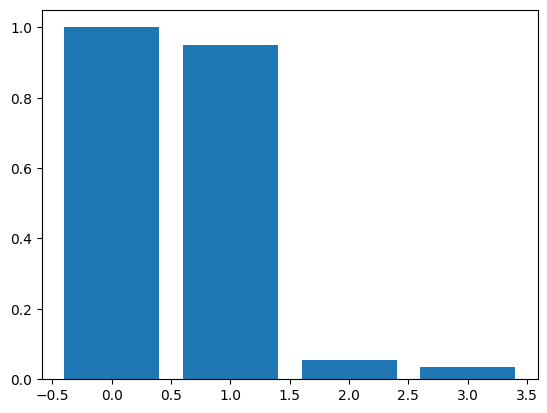

In [52]:
errors_1 = np.mean(np.sqrt(np.mean((preds_train_1.T - traj_test_out)**2, axis=0)/np.mean(traj_test_out**2, axis=0)))
errors_2 = np.mean(np.sqrt(np.mean((preds_train_1.T+preds_train_2.T - traj_test_out)**2, axis=0)/np.mean(traj_test_out**2, axis=0)))
errors_w = np.mean(np.sqrt(np.mean((preds_train_1.T+preds_train_2.T+preds_train_w.T - traj_test_out)**2, axis=0)/np.mean(traj_test_out**2, axis=0)))

plt.bar(np.arange(4), [1., errors_1, errors_2, errors_w]);

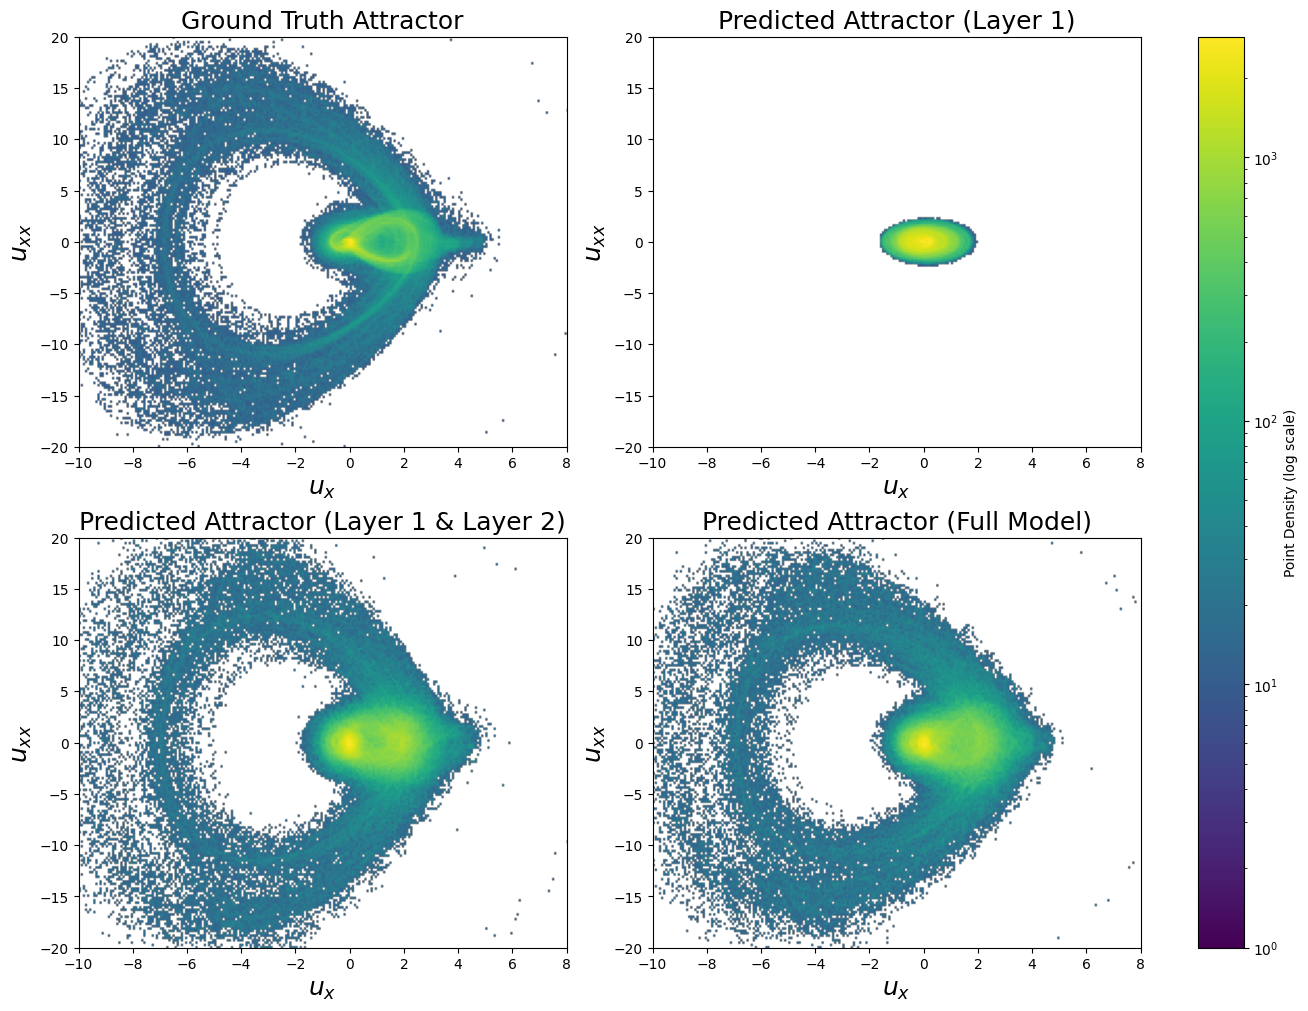

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def compute_spectral_derivatives(u, L):
    """
    Computes first and second spatial derivatives using FFT.
    u: 2D array (Time, Space)
    L: Domain length
    """
    u = np.asarray(u)
    nt, nx = u.shape

    # Calculate wavenumbers (2*pi*f)
    k = 2 * np.pi * np.fft.fftfreq(nx, d=L/nx)
    ik = 1j * k
    k2 = k**2

    # Fourier Transform along the spatial axis (axis=1)
    U_hat = np.fft.fft(u, axis=1)

    # Compute derivatives in Fourier space and transform back
    ux = np.fft.ifft(ik * U_hat, axis=1).real
    uxx = np.fft.ifft(-k2 * U_hat, axis=1).real

    return ux, uxx

def plot_attractor_density(u, L, ax, bins=350, xlim=None, ylim=None, log_density=True, title=None, xlim_eff=None, ylim_eff=None):
    """
    Generates a 2D histogram (phase portrait density) of ux vs uxx.
    """
    ux, uxx = compute_spectral_derivatives(u, L)
    
    # Flatten arrays for histogramming
    x_data = ux.ravel()
    y_data = uxx.ravel()

    # Determine limits based on percentiles if not provided
    if xlim is None:
        xlim = (np.percentile(x_data, 0.5), np.percentile(x_data, 99.5))
    if ylim is None:
        ylim = (np.percentile(y_data, 0.5), np.percentile(y_data, 99.5))

    # Compute 2D Histogram
    hist, x_edges, y_edges = np.histogram2d(x_data, y_data, bins=bins, range=[xlim, ylim])
    density_threshold = 10  # Threshold to filter out low-density bins
    hist = np.where(hist >= density_threshold, hist, 0)

    # Plotting configuration
    norm = LogNorm(vmin=1, vmax=hist.max()) if log_density else None
    
    im = ax.imshow(
        hist.T, origin="lower", 
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], 
        aspect="auto", cmap="viridis", norm=norm
    )

    ax.set_xlabel(r"$u_x$", fontsize=18)
    ax.set_ylabel(r"$u_{xx}$", fontsize=18)
    if title:
        ax.set_title(title, fontsize=18)
    
    if xlim_eff is not None:
        ax.set_xlim(xlim_eff)
    if ylim_eff is not None:
        ax.set_ylim(ylim_eff)

    return im

# --- Main Execution ---

# Setup parameters
L = 22.0
limit = 1000
true_data = datasets.output_test
with torch.no_grad():
    pred_data = model_hfno(datasets.input_test, indexes=[0], sum_w=False).cpu().numpy()
    pred_data_lay2 = model_hfno(datasets.input_test, indexes=[0,1], sum_w=False).cpu().numpy()
    pred_data_w = model_hfno(datasets.input_test).cpu().numpy()

# Global limits based on "True" data to ensure identical scales for comparison
ux_ref, uxx_ref = compute_spectral_derivatives(true_data, L)
shared_xlim = (np.percentile(ux_ref, 0.05), np.percentile(ux_ref, 99.5))
shared_ylim = (np.percentile(uxx_ref, 0.05), np.percentile(uxx_ref, 99.5))


shared_xlim_eff = [-10,8]
shared_ylim_eff = [-20,20]

# Create Figure
fig, ((ax_true, ax_pred_1), (ax_pred_2, ax_pred_w)) = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

# Plot True Data
im_true = plot_attractor_density(
    true_data, L, ax_true, 
    xlim=shared_xlim, ylim=shared_ylim, 
    title="Ground Truth Attractor",
    xlim_eff=shared_xlim_eff, ylim_eff=shared_ylim_eff
    
)

# Plot Predicted Data
im_pred_1 = plot_attractor_density(
    pred_data, L, ax_pred_1, 
    xlim=shared_xlim, ylim=shared_ylim, 
    title="Predicted Attractor (Layer 1)",
    xlim_eff=shared_xlim_eff, ylim_eff=shared_ylim_eff
)

im_pred_2 = plot_attractor_density(
    pred_data_lay2, L, ax_pred_2, 
    xlim=shared_xlim, ylim=shared_ylim, 
    title="Predicted Attractor (Layer 1 & Layer 2)",
    xlim_eff=shared_xlim_eff, ylim_eff=shared_ylim_eff
)

im_pred_w = plot_attractor_density(
    pred_data_w, L, ax_pred_w, 
    xlim=shared_xlim, ylim=shared_ylim, 
    title="Predicted Attractor (Full Model)",
    xlim_eff=shared_xlim_eff, ylim_eff=shared_ylim_eff
)

# Shared Colorbar
fig.colorbar(im_true, ax=[ax_true, ax_pred_1, ax_pred_2, ax_pred_w], label="Point Density (log scale)")

plt.show()

# Comparison with FNO

In [59]:
model_fno_path = "../../runs/kuramoto_sivashinsky/experiment_fno3"

config_path = os.path.join(model_fno_path, "config.yaml")
with open(config_path, "r") as f:
    args = yaml.safe_load(f)

model_fno = Factory.get_model(args["model"], args, device)
model_fno.load_state_dict(torch.load(os.path.join(model_fno_path, "model_weights", "min_test_loss.pth"))["model_state_dict"])

<All keys matched successfully>

In [60]:
sum(p.numel() for p in model_fno.parameters() if p.requires_grad)

852865

In [61]:
model_hfno.count_parameters()

36097

In [64]:
model_path = os.path.join(model_hfno_path, "logs/metrics.csv")
with open(model_path, "r") as f:
    metrics = pd.read_csv(f)
error_hfno = metrics["Te relative_rmse"].min()

In [65]:
with torch.no_grad():
    error = 0
    for input, target in datasets.testing_set:
        input_traj = torch.tensor(input, dtype=torch.float32).to(device)
        output_traj = model_fno(input_traj).cpu().numpy()
        target = target.cpu().numpy()
        error_batch = np.sqrt(np.mean((output_traj - target)**2, axis=1) / np.mean((target)**2, axis=1)).mean()
    error += error_batch
error /= len(datasets.testing_set)

/var/folders/53/d3ng48y138s7ldywsyn64jj00000gn/T/ipykernel_55670/823445227.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_traj = torch.tensor(input, dtype=torch.float32).to(device)


In [66]:
error.item()*100

0.7554430514574051

In [68]:
with torch.no_grad():
    preds_train_fno = model_fno(torch.tensor(traj_test, dtype=torch.float32).to(device))

/var/folders/53/d3ng48y138s7ldywsyn64jj00000gn/T/ipykernel_55670/2866361087.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  preds_train_fno = model_fno(torch.tensor(traj_test, dtype=torch.float32).to(device))


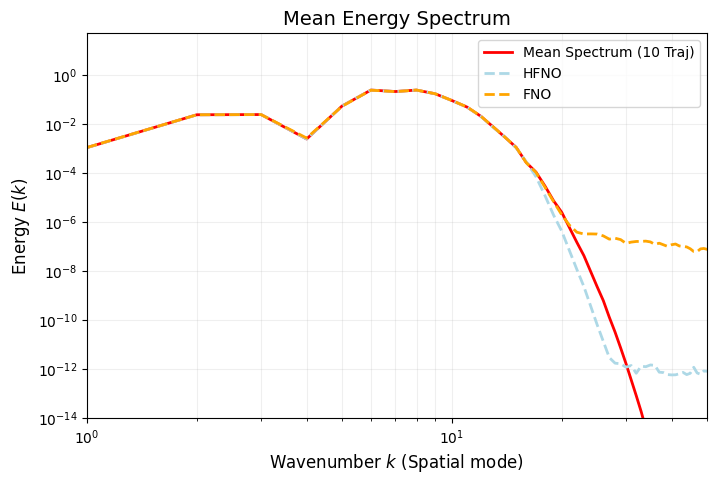

In [74]:
def energy_spectrum(u):
    nx, nt = u.shape 
    u_norm = u - np.mean(u, axis=0, keepdims=True)
    fft_u = np.fft.rfft(u_norm, axis=0)
    E_hat = np.mean(np.abs(fft_u)**2, axis=1) / (nx**2)
    kx = np.fft.rfftfreq(nx, d=1.0) * nx
    mask = E_hat > 0
    return E_hat[mask], kx[mask]

# --- Adapted Code for Mean Spectrum ---

#plt.figure(figsize=(8, 5))

k_shared = None

E_k, k = energy_spectrum(traj_test_out)
 
E_k__hfno, k_hfno = energy_spectrum(preds_train.T)
E_k_fno, k_fno = energy_spectrum(preds_train_fno.cpu().numpy().T)


#cumulative_energy = np.cumsum(mean_E_k)
#total_energy = cumulative_energy[-1]
#cumulative_energy /= total_energy  # normalize to [0,1]


#thresholds = [0.8, 0.95, 0.99]
#k_thresholds = []

#for t in thresholds:
#    idx = np.searchsorted(cumulative_energy, t)
#    k_thresholds.append(k[idx])

# --- Plot ---
plt.figure(figsize=(8, 5))

plt.loglog(k[1:], E_k[1:], color='red', lw=2, label="Mean Spectrum (10 Traj)")
plt.loglog(k_hfno[1:], E_k__hfno[1:], color='lightblue', lw=2, label="HFNO", linestyle='--')
plt.loglog(k_fno[1:], E_k_fno[1:], color='orange', lw=2, label="FNO", linestyle='--')


colors = ['blue', 'green', 'purple']
labels = ['80%', '95%', '99%']

#for k_val, c, lab in zip(k_thresholds, colors, labels):
#    plt.axvline(k_val, linestyle='--', color=c, label=f"{lab} energy (k={k_val:.1f})")

plt.title("Mean Energy Spectrum", fontsize=14)
plt.xlabel("Wavenumber $k$ (Spatial mode)", fontsize=12)
plt.ylabel("Energy $E(k)$", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlim(1, 50)
plt.ylim(1e-14, 50)
plt.legend()
plt.show();

In [79]:
metrics_hfno = pd.read_csv(os.path.join(model_hfno_path, f"logs/metrics.csv"))

In [80]:
metrics_fno = pd.read_csv(os.path.join(model_fno_path, "logs/metrics.csv"))

In [81]:
metrics_min_fno_mse = metrics_fno["Te relative_rmse"].min()
metrics_min_hfno_mse = metrics_hfno["Te relative_rmse"].min()

metrics_min_fno_mae = metrics_fno["Te relative_mae"].min()
metrics_min_hfno_mae = metrics_hfno["Te relative_mae"].min()

n_parameters_fno = sum(p.numel() for p in model_fno.parameters() if p.requires_grad)
n_parameters_hfno = model_hfno.count_parameters()

print(f"Minimum relative error for FNO: {metrics_min_fno_mse*100:.2f}%")
print(f"Minimum relative error for HFNO: {metrics_min_hfno_mse*100:.2f}%")
print(f"Minimum relative MAE for FNO: {metrics_min_fno_mae*100:.2f}%")
print(f"Minimum relative MAE for HFNO: {metrics_min_hfno_mae*100:.2f}%")
print(f"Number of parameters for FNO: {n_parameters_fno}")
print(f"Number of parameters for HFNO: {n_parameters_hfno}")

Minimum relative error for FNO: 1.54%
Minimum relative error for HFNO: 3.85%
Minimum relative MAE for FNO: 1.20%
Minimum relative MAE for HFNO: 3.74%
Number of parameters for FNO: 852865
Number of parameters for HFNO: 36097
